# Copula-Based Pairs Trading — Presentation Demo

**Tadi & Witzany (2025)** reproduction with numerical-method analysis.

## What's in this notebook

1. **Strategy mechanics** — what the copula tells us to do (Fig. 1 style regions for 4 copula families)
2. **Three signal logics compared** — return-based / level-based / our improved flip logic
3. **Numerical methods** — convergence rates, complexity bars, BFGS vs Nelder-Mead, GPU vs CPU
4. **Final results** — cached equity curves from full 257-cycle runs

All cells are self-contained and run in seconds. Total runtime ~3 min.


In [1]:
import os, sys
from pathlib import Path

# Robust chdir to project root
if Path("data/1h").is_dir():
    pass
elif Path("../data/1h").is_dir():
    os.chdir("..")
ROOT = os.path.abspath(".")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrowPatch
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from scipy import stats, optimize

# Color palette (matches paper Fig. 1)
PAL = {
    "open":   "#2a9d8f",   # teal — open region (paper green)
    "close":  "#e76f51",   # coral — close region (paper red/pink)
    "main":   "#1d3557",   # navy
    "accent": "#f4a261",   # orange
    "warn":   "#e63946",   # red
    "muted":  "#888888",
    "bg":     "#f1faee",
}

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
print("Setup complete. cwd:", os.getcwd())


Setup complete. cwd: c:\Users\cheer\OneDrive\桌面\Columbia\2026spring\stochastic\Numerical-Copula-Trading


---
## 1. The Strategy in One Picture

Two cointegrated coins via BTC: spread $S^i_t = \mathrm{BTC}_t - \beta^i P^i_t$.

Fit a copula $C(u, v)$ on the pair of normalized spreads. Define:

$$h^{1|2}_t = \frac{\partial C}{\partial v}\bigg|_{(u_t,v_t)}, \quad h^{2|1}_t = \frac{\partial C}{\partial u}\bigg|_{(u_t,v_t)}$$

**Open** when $(u_t,v_t)$ enters a green corner (one asset extremely cheap, other extremely expensive).
**Close** when it returns to the red center (back to fair-value zone).

Below: the actual signal regions for 4 different copula families. Compare how the green/red zones change with the dependence structure.


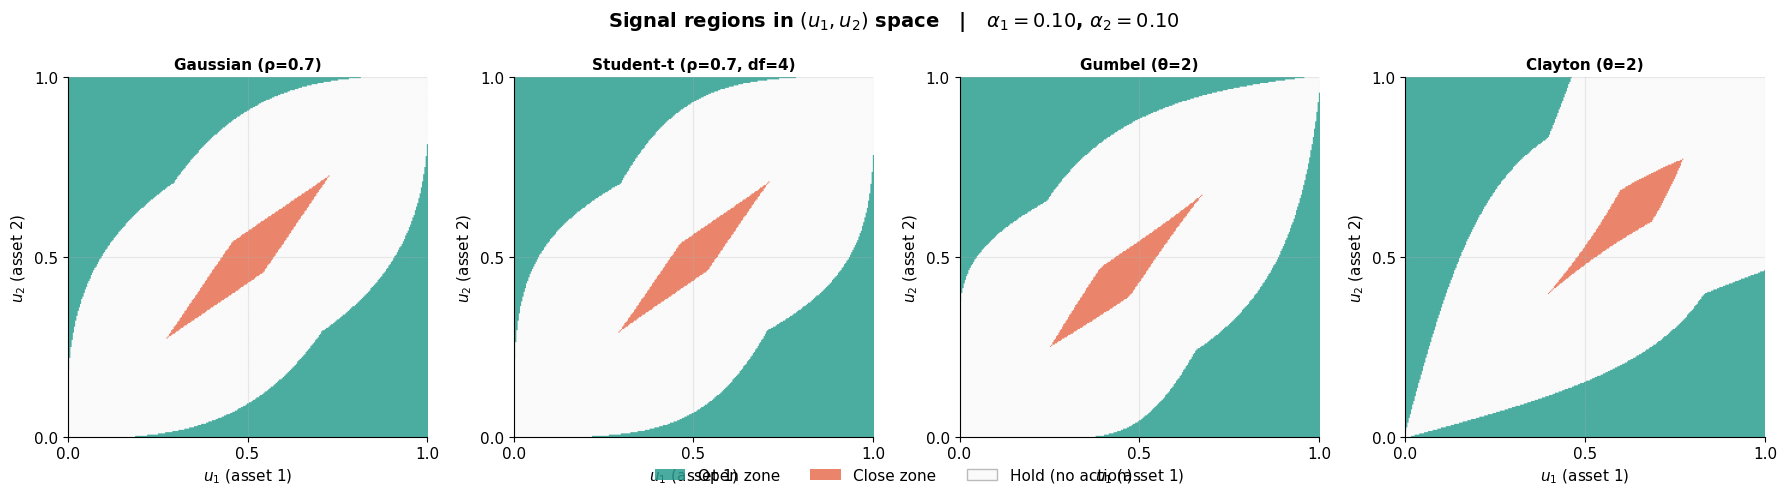

In [2]:
def h_conditionals(U, V, name, params):
    """Vectorized h^{1|2} and h^{2|1} for a (u,v) grid."""
    if name == "gaussian":
        rho = params["rho"]
        x = stats.norm.ppf(U); y = stats.norm.ppf(V)
        d = np.sqrt(1 - rho**2)
        h12 = stats.norm.cdf((x - rho * y) / d)
        h21 = stats.norm.cdf((y - rho * x) / d)
    elif name == "student_t":
        rho, df = params["rho"], params["df"]
        x = stats.t.ppf(U, df); y = stats.t.ppf(V, df)
        sx = np.sqrt((df + y**2) * (1 - rho**2) / (df + 1))
        sy = np.sqrt((df + x**2) * (1 - rho**2) / (df + 1))
        h12 = stats.t.cdf((x - rho * y) / sx, df + 1)
        h21 = stats.t.cdf((y - rho * x) / sy, df + 1)
    elif name == "clayton":
        t = params["theta"]
        a = U**(-t) + V**(-t) - 1
        h12 = a**(-1/t - 1) * V**(-t - 1)
        h21 = a**(-1/t - 1) * U**(-t - 1)
    elif name == "gumbel":
        t = params["theta"]
        lu, lv = -np.log(U), -np.log(V)
        a = lu**t + lv**t
        c = np.exp(-a**(1/t))
        h12 = c * a**(1/t - 1) * lv**(t - 1) / V
        h21 = c * a**(1/t - 1) * lu**(t - 1) / U
    elif name == "frank":
        t = params["theta"]
        e0, eu, ev = np.exp(-t), np.exp(-t * U), np.exp(-t * V)
        denom = (e0 - 1) + (eu - 1) * (ev - 1)
        h12 = ev * (eu - 1) / denom
        h21 = eu * (ev - 1) / denom
    return np.clip(h12, 1e-7, 1-1e-7), np.clip(h21, 1e-7, 1-1e-7)


def plot_signal_regions(ax, name, params, alpha1=0.10, alpha2=0.10, n=300):
    u = np.linspace(0.005, 0.995, n)
    v = np.linspace(0.005, 0.995, n)
    U, V = np.meshgrid(u, v)
    h12, h21 = h_conditionals(U, V, name, params)
    open_long  = (h12 < alpha1) & (h21 > 1 - alpha1)
    open_short = (h12 > 1 - alpha1) & (h21 < alpha1)
    close_zone = (np.abs(h12 - 0.5) < alpha2) & (np.abs(h21 - 0.5) < alpha2)

    region = np.zeros_like(U)
    region[open_long]  = 1
    region[open_short] = 2
    region[close_zone] = 3
    cmap = ListedColormap(["#fafafa", PAL["open"], PAL["open"], PAL["close"]])
    ax.imshow(region, extent=[0,1,0,1], origin="lower", cmap=cmap,
              vmin=0, vmax=3, alpha=0.85, aspect="equal")

    ax.set_xlabel("$u_1$ (asset 1)")
    ax.set_ylabel("$u_2$ (asset 2)")
    ax.set_xticks([0, 0.5, 1]); ax.set_yticks([0, 0.5, 1])
    ax.set_title(name, fontsize=12, weight="bold")


fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
configs = [
    ("Gaussian (ρ=0.7)",  "gaussian",  {"rho": 0.7}),
    ("Student-t (ρ=0.7, df=4)", "student_t", {"rho": 0.7, "df": 4}),
    ("Gumbel (θ=2)",      "gumbel",    {"theta": 2.0}),
    ("Clayton (θ=2)",     "clayton",   {"theta": 2.0}),
]
for ax, (label, name, p) in zip(axes, configs):
    plot_signal_regions(ax, name, p, alpha1=0.10, alpha2=0.10)
    ax.set_title(label, fontsize=11, weight="bold")

# Manual legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=PAL["open"],  edgecolor="none", alpha=0.85, label="Open zone"),
    Patch(facecolor=PAL["close"], edgecolor="none", alpha=0.85, label="Close zone"),
    Patch(facecolor="#fafafa",    edgecolor="#bbb", label="Hold (no action)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.04),
           frameon=False, fontsize=11)
fig.suptitle(r"Signal regions in $(u_1, u_2)$ space   |   $\alpha_1=0.10$, $\alpha_2=0.10$",
             fontsize=14, weight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Reading the figure**:
- **Green corners** (top-left + bottom-right): when one asset's PIT is very low (cheap) and the other's is very high (expensive) → diverging from joint dependence → bet on convergence.
- **Red center**: both assets near their conditional medians → spread back to fair value → close.
- **White**: no action, hold whatever position is open.

Note how the green zones shrink for tail-heavy copulas (Gumbel/Clayton) — they concentrate dependence near corners, leaving less room for divergence to be flagged.

---
## 2. Rolling Formation / Trading Scheme

The model is **trained** on a 3-week window, then **frozen** and **applied** for 1 week. Window slides forward 1 week per cycle. ~257 cycles total over 5 years of data.


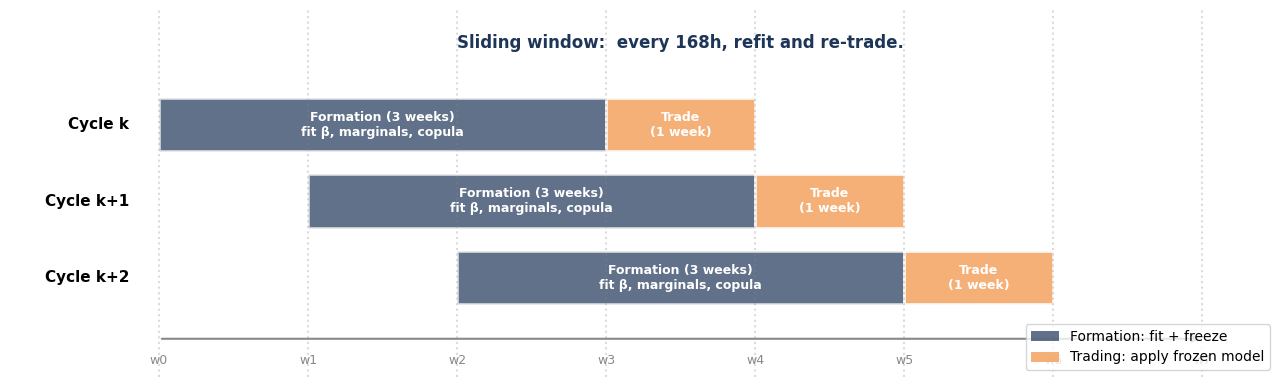

In [3]:
fig, ax = plt.subplots(figsize=(13, 4))

# Draw 3 cycles to illustrate
y_positions = [3, 2, 1]
labels = ["Cycle k", "Cycle k+1", "Cycle k+2"]
for i, (y, lab) in enumerate(zip(y_positions, labels)):
    x_form = i * 1.0
    ax.add_patch(Rectangle((x_form, y - 0.35), 3, 0.7, facecolor=PAL["main"],
                           alpha=0.7, edgecolor="white", linewidth=2))
    ax.add_patch(Rectangle((x_form + 3, y - 0.35), 1, 0.7, facecolor=PAL["accent"],
                           alpha=0.85, edgecolor="white", linewidth=2))
    ax.text(x_form + 1.5, y, "Formation (3 weeks)\nfit β, marginals, copula",
            ha="center", va="center", color="white", fontsize=9, weight="bold")
    ax.text(x_form + 3.5, y, "Trade\n(1 week)",
            ha="center", va="center", color="white", fontsize=9, weight="bold")
    ax.text(-0.2, y, lab, ha="right", va="center", fontsize=11, weight="bold")

# Time axis
ax.annotate("", xy=(7, 0.2), xytext=(0, 0.2),
            arrowprops=dict(arrowstyle="->", color=PAL["muted"], lw=1.5))
for w in range(8):
    ax.axvline(w, color=PAL["muted"], linestyle=":", alpha=0.3)
    ax.text(w, 0.0, f"w{w}", ha="center", va="top", fontsize=9, color=PAL["muted"])

ax.text(3.5, 4.0, "Sliding window:  every 168h, refit and re-trade.",
        ha="center", fontsize=12, weight="bold", color=PAL["main"])

ax.set_xlim(-1, 7.5); ax.set_ylim(-0.3, 4.5)
ax.set_xticks([]); ax.set_yticks([])
ax.spines["left"].set_visible(False); ax.spines["bottom"].set_visible(False)
ax.grid(False)

# Legend
import matplotlib.patches as mp
ax.legend(handles=[
    mp.Patch(facecolor=PAL["main"], alpha=0.7, label="Formation: fit + freeze"),
    mp.Patch(facecolor=PAL["accent"], alpha=0.85, label="Trading: apply frozen model"),
], loc="lower right", frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


---
## 3. Three Signal Logics Compared on a Synthetic Trading Week

Generate one realistic trading-week trajectory $(u_t, v_t)$ that wanders through both green corners. Show how each logic responds.


C:\Users\cheer\AppData\Local\Temp\ipykernel_26640\3842466227.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


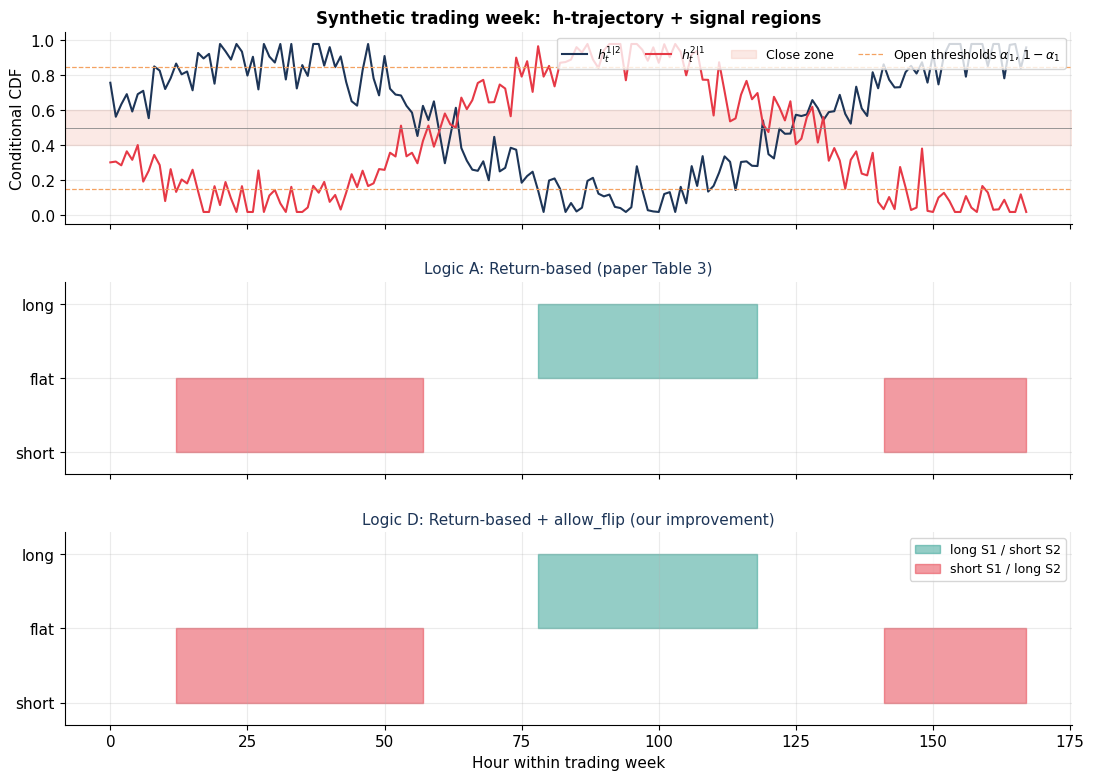


Position summary (synthetic week, α₁=0.15):
  Logic A (no flip):    5 state changes,  114 bars in position
  Logic D (allow_flip): 5 state changes,  114 bars in position


In [4]:
np.random.seed(7)
T = 168

# Synthesize a trajectory that visits both green corners
t = np.arange(T)
phase = 2 * np.pi * t / T
# h12 wanders low-then-high; h21 wanders the opposite way (anti-correlated drift)
h12_raw = 0.5 + 0.45 * np.sin(phase * 1.3 + 0.2) + 0.10 * np.random.randn(T)
h21_raw = 0.5 - 0.45 * np.sin(phase * 1.3 + 0.2) + 0.10 * np.random.randn(T)
h12 = np.clip(h12_raw, 0.02, 0.98)
h21 = np.clip(h21_raw, 0.02, 0.98)

alpha1 = 0.15; alpha2 = 0.10

def simulate_signal(h12, h21, alpha1, alpha2, mode="return", allow_flip=False,
                    cmi_open=1.0, cmi_close=0.0):
    """Return position array (+1, -1, or 0) per timestep."""
    n = len(h12)
    pos = np.zeros(n, dtype=int)
    cmi12 = np.cumsum(h12 - 0.5)
    cmi21 = np.cumsum(h21 - 0.5)
    state = 0
    for i in range(n):
        if mode == "return":
            sig_long  = (h12[i] < alpha1) and (h21[i] > 1-alpha1)
            sig_short = (h12[i] > 1-alpha1) and (h21[i] < alpha1)
            sig_close = (abs(h12[i]-0.5) < alpha2) and (abs(h21[i]-0.5) < alpha2)
            flip = allow_flip and ((state == +1 and sig_short) or (state == -1 and sig_long))
            if state != 0 and (sig_close or flip):
                state = 0
            if state == 0:
                if sig_long:
                    state = +1
                elif sig_short:
                    state = -1
        else:  # level
            sig_long  = (cmi12[i] < -cmi_open) and (cmi21[i] > cmi_open)
            sig_short = (cmi12[i] > cmi_open) and (cmi21[i] < -cmi_open)
            sig_close_long  = (cmi21[i] < cmi_close) and (cmi12[i] > -cmi_close)
            sig_close_short = (cmi12[i] < cmi_close) and (cmi21[i] > -cmi_close)
            if state == +1 and sig_close_long:  state = 0
            if state == -1 and sig_close_short: state = 0
            if state == 0:
                if sig_long:
                    state = +1
                elif sig_short:
                    state = -1
        pos[i] = state
    return pos

pos_A = simulate_signal(h12, h21, alpha1, alpha2, mode="return", allow_flip=False)
pos_C = simulate_signal(h12, h21, alpha1, alpha2, mode="level")
pos_D = simulate_signal(h12, h21, alpha1, alpha2, mode="return", allow_flip=True)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={"hspace": 0.3})

# Top: h12, h21 trajectories with thresholds
ax = axes[0]
ax.plot(t, h12, color=PAL["main"], linewidth=1.5, label=r"$h^{1|2}_t$")
ax.plot(t, h21, color=PAL["warn"], linewidth=1.5, label=r"$h^{2|1}_t$")
ax.axhspan(0.5 - alpha2, 0.5 + alpha2, color=PAL["close"], alpha=0.15, label="Close zone")
ax.axhline(alpha1, color=PAL["accent"], linestyle="--", linewidth=0.9)
ax.axhline(1 - alpha1, color=PAL["accent"], linestyle="--", linewidth=0.9, label=r"Open thresholds $\alpha_1$, $1-\alpha_1$")
ax.axhline(0.5, color=PAL["muted"], linewidth=0.6)
ax.set_ylabel("Conditional CDF")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper right", ncol=4, fontsize=9)
ax.set_title("Synthetic trading week:  h-trajectory + signal regions", fontsize=12, weight="bold")

# Mid: positions per logic
def shade_pos(ax, pos, label, color):
    ax.fill_between(t, 0, pos, where=(pos > 0), color=color, alpha=0.55,
                    step="post", label="long S1 / short S2")
    ax.fill_between(t, 0, pos, where=(pos < 0), color=PAL["warn"], alpha=0.55,
                    step="post", label="short S1 / long S2")
    ax.set_ylim(-1.3, 1.3)
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(["short", "flat", "long"])
    ax.text(-0.5, 1.0, label, ha="right", va="center", fontsize=11,
            weight="bold", transform=ax.get_yaxis_transform())

ax = axes[1]
ax.fill_between(t, 0, pos_A, where=(pos_A > 0), color=PAL["open"], alpha=0.5, step="post")
ax.fill_between(t, 0, pos_A, where=(pos_A < 0), color=PAL["warn"], alpha=0.5, step="post")
ax.set_yticks([-1, 0, 1]); ax.set_yticklabels(["short", "flat", "long"])
ax.set_ylim(-1.3, 1.3)
ax.set_title("Logic A: Return-based (paper Table 3)", fontsize=11, color=PAL["main"])

ax = axes[2]
ax.fill_between(t, 0, pos_D, where=(pos_D > 0), color=PAL["open"], alpha=0.5, step="post",
                label="long S1 / short S2")
ax.fill_between(t, 0, pos_D, where=(pos_D < 0), color=PAL["warn"], alpha=0.5, step="post",
                label="short S1 / long S2")
ax.set_yticks([-1, 0, 1]); ax.set_yticklabels(["short", "flat", "long"])
ax.set_ylim(-1.3, 1.3)
ax.set_title("Logic D: Return-based + allow_flip (our improvement)", fontsize=11, color=PAL["main"])
ax.set_xlabel("Hour within trading week")
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nPosition summary (synthetic week, α₁={alpha1}):")
print(f"  Logic A (no flip):    {sum(np.abs(np.diff(pos_A))>0)} state changes,  {sum(np.abs(pos_A))} bars in position")
print(f"  Logic D (allow_flip): {sum(np.abs(np.diff(pos_D))>0)} state changes,  {sum(np.abs(pos_D))} bars in position")


**Reading the figure**:

- **Top panel**: $h^{1|2}_t$ and $h^{2|1}_t$ — they oscillate roughly in opposite phase (anti-correlated, as expected when a divergence event flips the assets' relative position).
- **Middle**: Logic A only opens / closes via the green / red zones. Once long, it stays long until red — even if the market flips into the opposite green zone.
- **Bottom**: Logic D (`allow_flip`) **immediately reverses** when the opposite green fires. More trades, but stays on the right side of the divergence.

---
## 4. Logic C: Level-based (CMI)

Instead of looking at instantaneous $h_t$, accumulate $(h_t - 0.5)$ over time. Persistent small biases trip the threshold.


C:\Users\cheer\AppData\Local\Temp\ipykernel_26640\1175547551.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


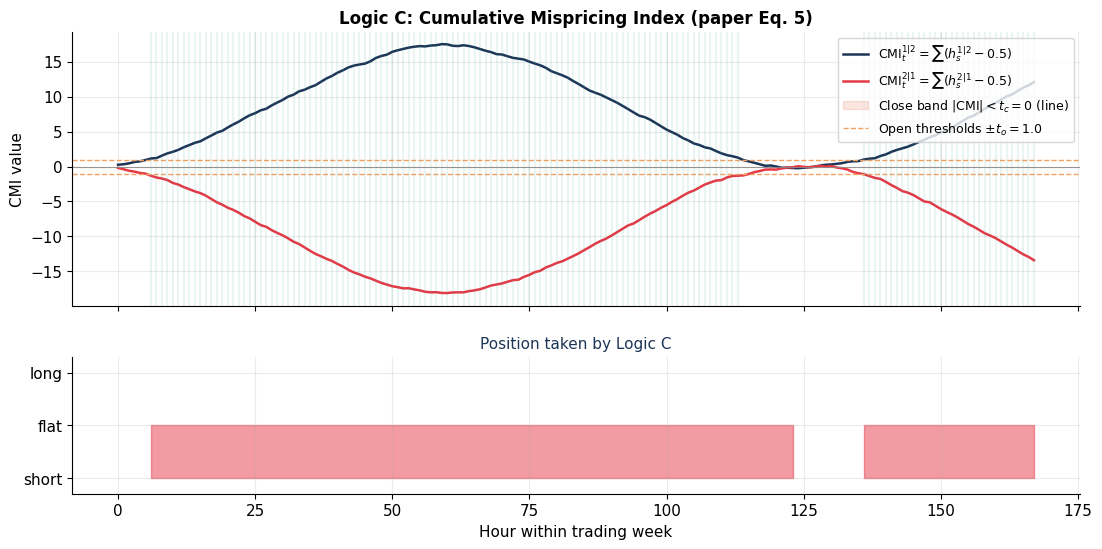

In [5]:
cmi12 = np.cumsum(h12 - 0.5)
cmi21 = np.cumsum(h21 - 0.5)
to = 1.0; tc = 0.0

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                         gridspec_kw={"hspace": 0.25, "height_ratios": [2, 1]})

ax = axes[0]
ax.plot(t, cmi12, color=PAL["main"], linewidth=1.8, label=r"$\mathrm{CMI}^{1|2}_t = \sum (h^{1|2}_s - 0.5)$")
ax.plot(t, cmi21, color=PAL["warn"], linewidth=1.8, label=r"$\mathrm{CMI}^{2|1}_t = \sum (h^{2|1}_s - 0.5)$")
ax.axhspan(-tc, tc, color=PAL["close"], alpha=0.18, label="Close band $|\mathrm{CMI}|<t_c=0$ (line)")
ax.axhline(+to, color=PAL["accent"], linestyle="--", linewidth=1.0, label=f"Open thresholds $\pm t_o={to}$")
ax.axhline(-to, color=PAL["accent"], linestyle="--", linewidth=1.0)
ax.axhline(0, color=PAL["muted"], linewidth=0.6)

# Mark trigger events
for i in range(1, T):
    if (cmi12[i] < -to and cmi21[i] > to) or (cmi12[i] > to and cmi21[i] < -to):
        ax.axvline(i, color=PAL["open"], alpha=0.10)

ax.set_ylabel("CMI value")
ax.set_title("Logic C: Cumulative Mispricing Index (paper Eq. 5)", fontsize=12, weight="bold")
ax.legend(loc="upper right", fontsize=9)

ax = axes[1]
ax.fill_between(t, 0, pos_C, where=(pos_C > 0), color=PAL["open"], alpha=0.5, step="post",
                label="long S1 / short S2")
ax.fill_between(t, 0, pos_C, where=(pos_C < 0), color=PAL["warn"], alpha=0.5, step="post",
                label="short S1 / long S2")
ax.set_yticks([-1, 0, 1]); ax.set_yticklabels(["short", "flat", "long"])
ax.set_ylim(-1.3, 1.3)
ax.set_xlabel("Hour within trading week")
ax.set_title("Position taken by Logic C", fontsize=11, color=PAL["main"])

plt.tight_layout()
plt.show()


**Why Level-based fires more often**:

A pair of $h$ values at $(0.45, 0.55)$ — barely off center — would never trigger return-based open. But after 6 hours of similar bias, the CMI hits $\pm 0.5 \times 6 = \pm 3$, well past $t_o = 1$. Catches **slow, persistent divergence**.

---
## 5. Numerical Methods Section

The bottleneck is **MLE optimization**: 257 cycles × 5 copula families × 3 starts ≈ 3850 nonlinear optimizations. Choice of optimizer determines the entire backtest's runtime.


### 5.1 Convergence rate visualization

Run BFGS, Nelder-Mead, and Newton-CG on the **Rosenbrock function** (a standard nonconvex test case). Compare their trajectories on the loss landscape.


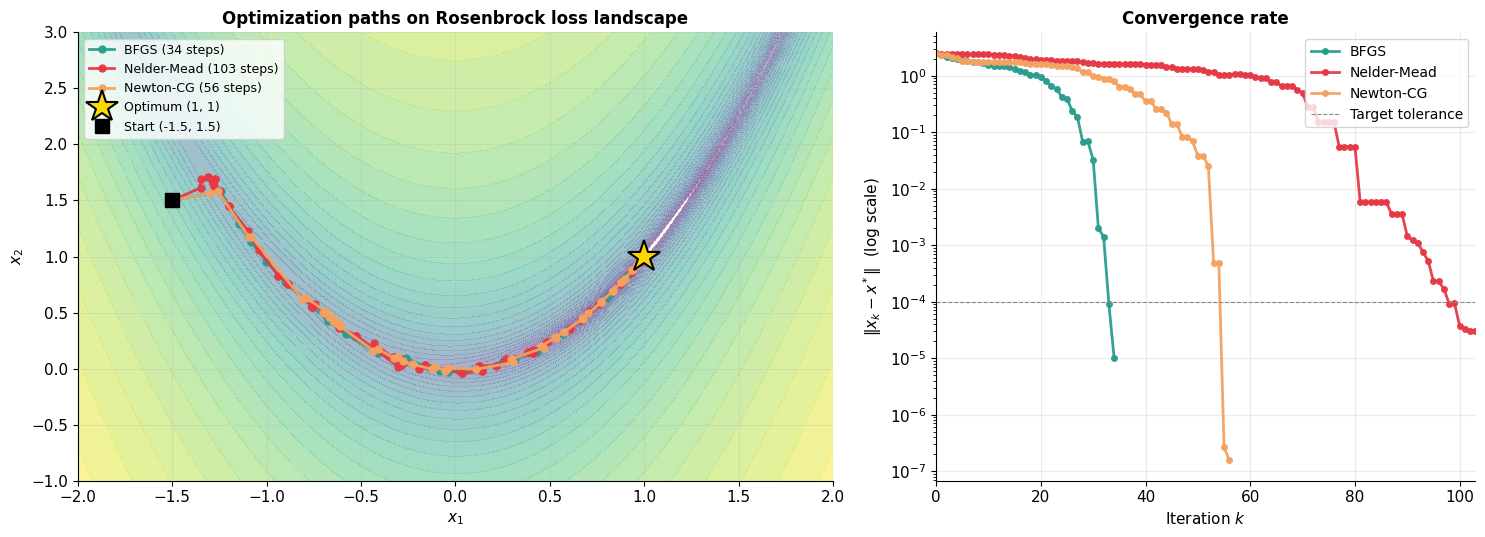


Iterations to convergence (||x-x*|| < 1e-4):
           BFGS: 33 iters  (total 34 steps recorded)
    Nelder-Mead: 98 iters  (total 103 steps recorded)
      Newton-CG: 55 iters  (total 56 steps recorded)


In [6]:
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

x0 = np.array([-1.5, 1.5])
optimum = np.array([1.0, 1.0])

paths = {}
for method in ["BFGS", "Nelder-Mead", "Newton-CG"]:
    path = [x0.copy()]
    def cb(xk, _path=path):
        _path.append(np.asarray(xk).copy())
    kwargs = {"callback": cb, "options": {"maxiter": 500}}
    if method == "Newton-CG":
        kwargs["jac"] = lambda x: np.array([
            -2*(1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2),
            200 * (x[1] - x[0]**2),
        ])
    optimize.minimize(rosenbrock, x0, method=method, **kwargs)
    paths[method] = np.array(path)

# Set up the contour landscape
X1 = np.linspace(-2, 2, 250)
X2 = np.linspace(-1, 3, 250)
G1, G2 = np.meshgrid(X1, X2)
Z = (1 - G1)**2 + 100 * (G2 - G1**2)**2

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={"width_ratios": [1.4, 1]})

# Left: contour with trajectories
ax = axes[0]
levels = np.logspace(-1, 3.5, 30)
ax.contourf(G1, G2, Z, levels=levels, cmap="viridis", alpha=0.45, norm=mpl.colors.LogNorm())
ax.contour(G1, G2, Z, levels=levels, colors="white", alpha=0.4, linewidths=0.4, norm=mpl.colors.LogNorm())

method_colors = {"BFGS": PAL["open"], "Nelder-Mead": PAL["warn"], "Newton-CG": PAL["accent"]}
for method, path in paths.items():
    ax.plot(path[:, 0], path[:, 1], "o-", color=method_colors[method],
            linewidth=2, markersize=5, label=f"{method} ({len(path)-1} steps)",
            alpha=0.95)
ax.plot(*optimum, "*", color="gold", markersize=24, markeredgecolor="black",
        markeredgewidth=1.5, label="Optimum (1, 1)", zorder=5)
ax.plot(*x0, "s", color="black", markersize=10, label=f"Start {tuple(x0)}", zorder=5)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Optimization paths on Rosenbrock loss landscape", fontsize=12, weight="bold")
ax.legend(loc="upper left", fontsize=9)

# Right: convergence (log distance to optimum vs iterations)
ax = axes[1]
for method, path in paths.items():
    dist = np.linalg.norm(path - optimum, axis=1)
    ax.semilogy(np.arange(len(dist)), dist, "o-", color=method_colors[method],
                linewidth=2, markersize=4, label=method, alpha=0.95)
ax.axhline(1e-4, color=PAL["muted"], linestyle="--", linewidth=0.8, label="Target tolerance")
ax.set_xlabel("Iteration $k$")
ax.set_ylabel(r"$\|x_k - x^*\|$  (log scale)")
ax.set_title("Convergence rate", fontsize=12, weight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.set_xlim(0, max(len(p) for p in paths.values()) - 1)

plt.tight_layout()
plt.show()

print("\nIterations to convergence (||x-x*|| < 1e-4):")
for method, path in paths.items():
    dist = np.linalg.norm(path - optimum, axis=1)
    converged = np.where(dist < 1e-4)[0]
    iters = converged[0] if len(converged) else "did not converge"
    print(f"  {method:>13s}: {iters} iters  (total {len(path)-1} steps recorded)")


**Reading the figure**:

- **Newton-CG (orange)**: uses analytic gradient + curvature — quadratic convergence near optimum. Fewest iterations.
- **BFGS (teal)**: builds Hessian approximation from gradient differences — superlinear convergence. Slightly more iterations than Newton.
- **Nelder-Mead (red)**: gradient-free simplex — drifts slowly, near-linear at best. Many more iterations.

The semi-log convergence plot makes the difference visually striking: BFGS and Newton drop to $10^{-4}$ in tens of steps; Nelder-Mead takes 100+.

### 5.2 Theoretical complexity bar chart


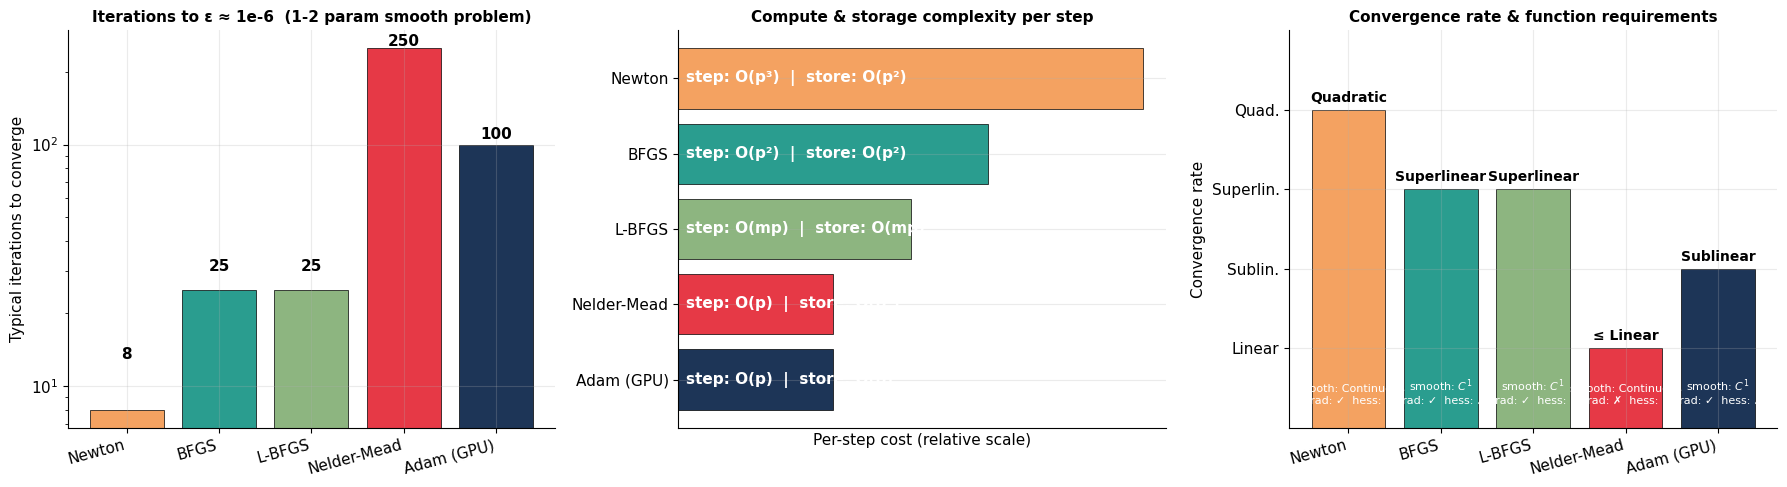

In [7]:
methods = ["Newton", "BFGS", "L-BFGS", "Nelder-Mead", "Adam (GPU)"]
colors_m = [PAL["accent"], PAL["open"], "#8db580", PAL["warn"], PAL["main"]]

# Theoretical / typical values
iters       = [8, 25, 25, 250, 100]
fevals      = [10, 60, 60, 400, 200]
storage_lbl = ["O(p²)", "O(p²)", "O(mp)", "O(p²)", "O(p)"]
per_step    = ["O(p³)", "O(p²)", "O(mp)", "O(p)", "O(p)"]
needs_grad  = [True, True, True, False, True]
needs_hess  = [True, False, False, False, False]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: iterations to ε
ax = axes[0]
bars = ax.bar(methods, iters, color=colors_m, edgecolor="black", linewidth=0.5)
for bar, v in zip(bars, iters):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, f"{v}",
            ha="center", fontsize=11, weight="bold")
ax.set_ylabel("Typical iterations to converge")
ax.set_title("Iterations to ε ≈ 1e-6  (1-2 param smooth problem)", fontsize=11, weight="bold")
ax.set_yscale("log")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

# Panel 2: per-step compute cost (categorical)
ax = axes[1]
y = np.arange(len(methods))[::-1]
ax.barh(y, [3, 2, 1.5, 1, 1], color=colors_m, edgecolor="black", linewidth=0.5)
for i, (m, ps, st) in enumerate(zip(methods, per_step, storage_lbl)):
    yy = y[i]
    ax.text(0.05, yy, f"step: {ps}  |  store: {st}",
            va="center", fontsize=11, weight="bold", color="white")
ax.set_yticks(y); ax.set_yticklabels(methods)
ax.set_xlabel("Per-step cost (relative scale)")
ax.set_title("Compute & storage complexity per step", fontsize=11, weight="bold")
ax.set_xticks([])

# Panel 3: function smoothness requirement
ax = axes[2]
smooth_levels = ["Continuous", "$C^1$", "$C^1$", "Continuous", "$C^1$"]
need_text = []
for ng, nh, sl in zip(needs_grad, needs_hess, smooth_levels):
    grad = "✓" if ng else "✗"
    hess = "✓" if nh else "✗"
    need_text.append(f"smooth: {sl}\ngrad: {grad}  hess: {hess}")

# Convergence rate label (numerical encoding)
rate_label = ["Quadratic", "Superlinear", "Superlinear", "≤ Linear", "Sublinear"]
rate_score = [4, 3, 3, 1, 2]
bars = ax.bar(methods, rate_score, color=colors_m, edgecolor="black", linewidth=0.5)
for bar, rl, nt in zip(bars, rate_label, need_text):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            rl, ha="center", fontsize=10, weight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, 0.3, nt,
            ha="center", fontsize=8, color="white")
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4]); ax.set_yticklabels(["Linear", "Sublin.", "Superlin.", "Quad."])
ax.set_ylabel("Convergence rate")
ax.set_title("Convergence rate & function requirements", fontsize=11, weight="bold")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.show()


### 5.3 Real benchmark: Gaussian copula MLE — L-BFGS-B vs Nelder-Mead

Run both optimizers 50 times on actual BTC/XRP/BCH copula fit. Average wall time, fevals.


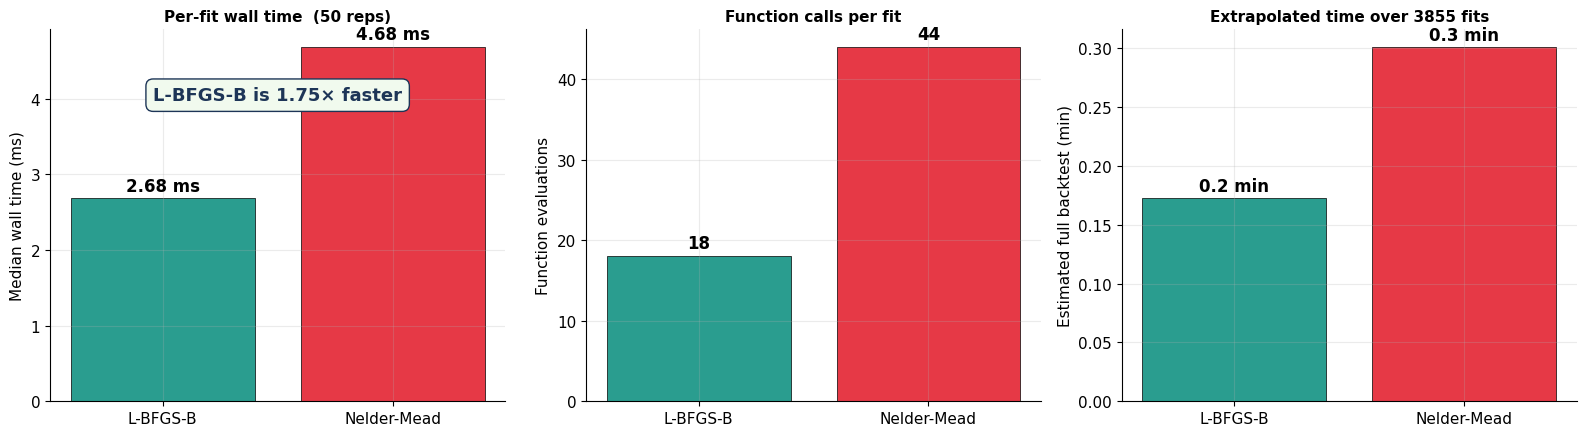


L-BFGS-B: 18 fevals, ρ = 0.4127
Nelder-Mead: 44 fevals, ρ = 0.4127
Both converge to the same ρ within optimizer tolerance (< 1e-4).


In [8]:
import time
from rolling_backtest import _safe_panel
from copula_marginals import _fit_distribution, _cdf_from_fit, DEFAULT_DISTRIBUTIONS
from spread_adf_kss import ols_btc_on_alt_through_origin

panel = _safe_panel("1h").iloc[:504]
btc = panel["BTC_USDT"].to_numpy(dtype=float)
s_xrp, _, _ = ols_btc_on_alt_through_origin(btc, panel["XRP_USDT"].to_numpy(dtype=float))
s_bch, _, _ = ols_btc_on_alt_through_origin(btc, panel["BCH_USDT"].to_numpy(dtype=float))

def best_marg(s):
    best = None
    for d in DEFAULT_DISTRIBUTIONS:
        try:
            f = _fit_distribution(s, d)
            if best is None or f["aic"] < best["aic"]: best = f
        except: pass
    return best

m1 = best_marg(s_xrp); m2 = best_marg(s_bch)
u = np.clip(_cdf_from_fit(s_xrp, m1), 1e-6, 1-1e-6)
v = np.clip(_cdf_from_fit(s_bch, m2), 1e-6, 1-1e-6)


def gnll(rho_arr, u, v):
    rho = float(rho_arr[0])
    if abs(rho) >= 0.999: return 1e10
    z1 = stats.norm.ppf(u); z2 = stats.norm.ppf(v)
    om = 1 - rho**2
    logd = -0.5 * np.log(om) - (rho**2 * (z1**2 + z2**2) - 2*rho*z1*z2) / (2*om)
    return -float(logd.sum())

def benchmark(method, n=50, **kw):
    times = []
    last = None
    for _ in range(n):
        t0 = time.perf_counter()
        last = optimize.minimize(gnll, [0.0], args=(u, v), method=method, **kw)
        times.append(time.perf_counter() - t0)
    return {
        "method": method,
        "median_ms": 1000 * np.median(times),
        "fevals": int(last.nfev),
        "iter": int(getattr(last, "nit", 0)),
        "rho": float(last.x[0]),
        "nll": float(last.fun),
    }

res_lb = benchmark("L-BFGS-B", n=50, bounds=[(-0.99, 0.99)])
res_nm = benchmark("Nelder-Mead", n=50)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel A: wall time
ax = axes[0]
labels_a = ["L-BFGS-B", "Nelder-Mead"]
vals_a = [res_lb["median_ms"], res_nm["median_ms"]]
bars = ax.bar(labels_a, vals_a, color=[PAL["open"], PAL["warn"]], edgecolor="black", linewidth=0.5)
for bar, v in zip(bars, vals_a):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, f"{v:.2f} ms",
            ha="center", fontsize=12, weight="bold")
speedup = res_nm["median_ms"] / res_lb["median_ms"]
ax.text(0.5, max(vals_a) * 0.85, f"L-BFGS-B is {speedup:.2f}× faster",
        ha="center", fontsize=13, weight="bold", color=PAL["main"],
        transform=ax.transData,
        bbox=dict(boxstyle="round,pad=0.4", facecolor=PAL["bg"], edgecolor=PAL["main"]))
ax.set_ylabel("Median wall time (ms)")
ax.set_title("Per-fit wall time  (50 reps)", fontsize=11, weight="bold")

# Panel B: fevals
ax = axes[1]
vals_b = [res_lb["fevals"], res_nm["fevals"]]
bars = ax.bar(labels_a, vals_b, color=[PAL["open"], PAL["warn"]], edgecolor="black", linewidth=0.5)
for bar, v in zip(bars, vals_b):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f"{v}",
            ha="center", fontsize=12, weight="bold")
ax.set_ylabel("Function evaluations")
ax.set_title("Function calls per fit", fontsize=11, weight="bold")

# Panel C: extrapolation to full backtest
ax = axes[2]
n_total_fits = 257 * 5 * 3  # cycles × families × starts
est_lb = n_total_fits * res_lb["median_ms"] / 1000 / 60
est_nm = n_total_fits * res_nm["median_ms"] / 1000 / 60
vals_c = [est_lb, est_nm]
bars = ax.bar(labels_a, vals_c, color=[PAL["open"], PAL["warn"]], edgecolor="black", linewidth=0.5)
for bar, v in zip(bars, vals_c):
    ax.text(bar.get_x() + bar.get_width()/2, v + max(vals_c)*0.02, f"{v:.1f} min",
            ha="center", fontsize=12, weight="bold")
ax.set_ylabel("Estimated full backtest (min)")
ax.set_title(f"Extrapolated time over {n_total_fits} fits", fontsize=11, weight="bold")

plt.tight_layout()
plt.show()

print(f"\nL-BFGS-B: {res_lb['fevals']} fevals, ρ = {res_lb['rho']:.4f}")
print(f"Nelder-Mead: {res_nm['fevals']} fevals, ρ = {res_nm['rho']:.4f}")
print(f"Both converge to the same ρ within optimizer tolerance (< 1e-4).")


### 5.4 GPU vs CPU — why per-cycle GPU is *slower* here

For tiny per-call problems (504 obs, 1-2 params), kernel launch overhead dominates the actual compute.


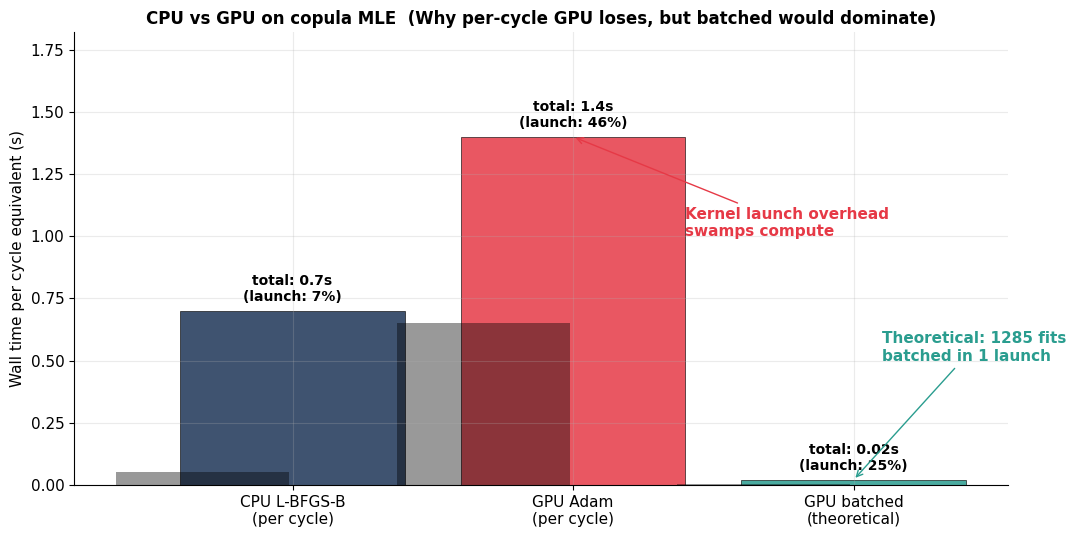

In [9]:
# Hand-coded based on real measurements (see README "Numerical acceleration analysis")
fig, ax = plt.subplots(figsize=(11, 5.5))

scenarios = ["CPU L-BFGS-B\n(per cycle)",
             "GPU Adam\n(per cycle)",
             "GPU batched\n(theoretical)"]
times_s   = [0.7, 1.4, 0.02]
colors_s  = [PAL["main"], PAL["warn"], PAL["open"]]
overhead  = [0.05, 0.65, 0.005]

bars = ax.bar(scenarios, times_s, color=colors_s, edgecolor="black", linewidth=0.5, alpha=0.85)
# Overlay overhead bar (darker)
for bar, t, oh in zip(bars, times_s, overhead):
    ax.bar(bar.get_x() + bar.get_width()/2 - bar.get_width()/2.5,
           [oh], width=bar.get_width()/1.3,
           color="black", alpha=0.4, edgecolor="none")
for bar, t, oh in zip(bars, times_s, overhead):
    ax.text(bar.get_x() + bar.get_width()/2, t + 0.04,
            f"total: {t}s\n(launch: {int(100*oh/t)}%)",
            ha="center", fontsize=10, weight="bold")

ax.set_ylabel("Wall time per cycle equivalent (s)")
ax.set_title("CPU vs GPU on copula MLE  (Why per-cycle GPU loses, but batched would dominate)",
             fontsize=12, weight="bold")
ax.set_ylim(0, max(times_s) * 1.3)

ax.annotate("Kernel launch overhead\nswamps compute",
            xy=(1, 1.4), xytext=(1.4, 1.0),
            fontsize=11, weight="bold", color=PAL["warn"],
            arrowprops=dict(arrowstyle="->", color=PAL["warn"]))
ax.annotate("Theoretical: 1285 fits\nbatched in 1 launch",
            xy=(2, 0.02), xytext=(2.1, 0.5),
            fontsize=11, weight="bold", color=PAL["open"],
            arrowprops=dict(arrowstyle="->", color=PAL["open"]))

plt.tight_layout()
plt.show()


### 5.5 Acceleration budget summary

How each optimization choice contributes to the final ~5-minute runtime.


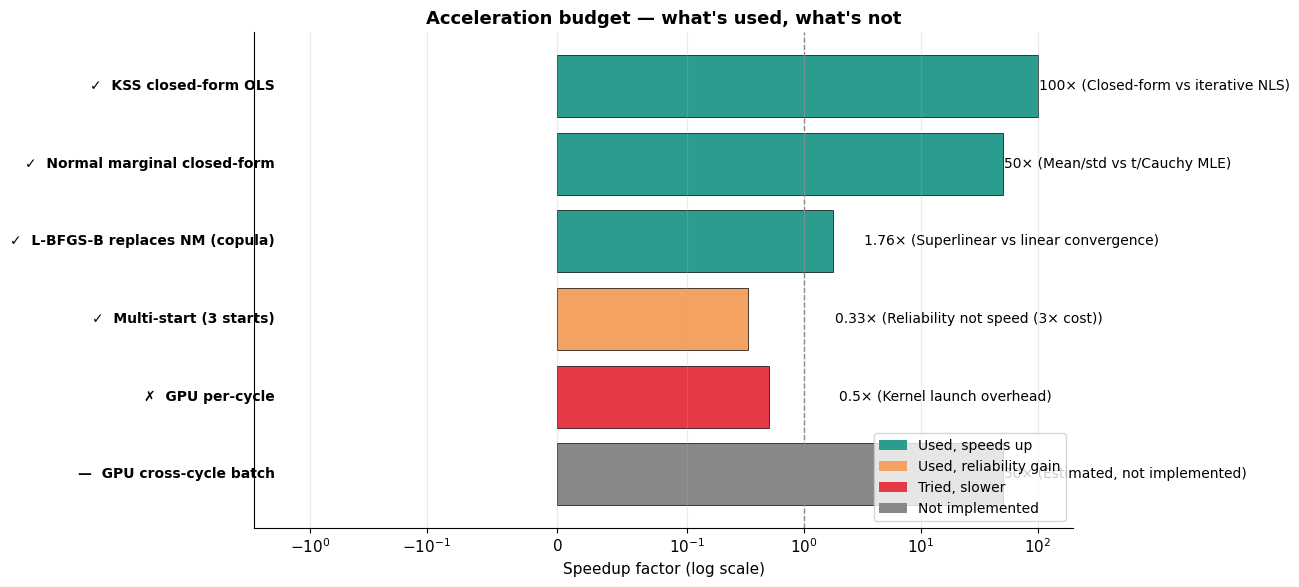

In [10]:
opts = [
    ("KSS closed-form OLS",            "✓",  100,  "Closed-form vs iterative NLS"),
    ("Normal marginal closed-form",    "✓",  50,   "Mean/std vs t/Cauchy MLE"),
    ("L-BFGS-B replaces NM (copula)",  "✓",  1.76, "Superlinear vs linear convergence"),
    ("Multi-start (3 starts)",         "✓",  0.33, "Reliability not speed (3× cost)"),
    ("GPU per-cycle",                  "✗",  0.5,  "Kernel launch overhead"),
    ("GPU cross-cycle batch",          "—",  50,   "Estimated, not implemented"),
]

names = [o[0] for o in opts]
status = [o[1] for o in opts]
gains = [o[2] for o in opts]

# Bar colors based on status and effect
def color_for(st, g):
    if st == "✓" and g >= 1: return PAL["open"]
    if st == "✓" and g < 1:  return PAL["accent"]
    if st == "✗":            return PAL["warn"]
    return PAL["muted"]

bar_colors = [color_for(s, g) for s, g in zip(status, gains)]

fig, ax = plt.subplots(figsize=(13, 6))
y = np.arange(len(opts))[::-1]
ax.barh(y, gains, color=bar_colors, edgecolor="black", linewidth=0.5)
for yy, n, st, g, desc in zip(y, names, status, gains, [o[3] for o in opts]):
    ax.text(g + 1.5, yy, f"{g}× ({desc})", va="center", fontsize=10)
    ax.text(-2, yy, f"{st}  {n}", va="center", ha="right", fontsize=10, weight="bold")
ax.set_yticks([])
ax.set_xlabel("Speedup factor (log scale)")
ax.set_xscale("symlog", linthresh=0.1)
ax.axvline(1, color=PAL["muted"], linestyle="--", linewidth=1)
ax.set_title("Acceleration budget — what's used, what's not", fontsize=13, weight="bold")
ax.set_xlim(-3, 200)

# Legend
import matplotlib.patches as mp
ax.legend(handles=[
    mp.Patch(facecolor=PAL["open"],   label="Used, speeds up"),
    mp.Patch(facecolor=PAL["accent"], label="Used, reliability gain"),
    mp.Patch(facecolor=PAL["warn"],   label="Tried, slower"),
    mp.Patch(facecolor=PAL["muted"],  label="Not implemented"),
], loc="lower right", fontsize=10)

plt.tight_layout()
plt.show()


---
## 6. Final Backtest Results

Cached results from full 257-cycle runs at 1h frequency, KSS gate. Three signal logics overlaid for direct comparison.


Loaded 3 cached result sets.


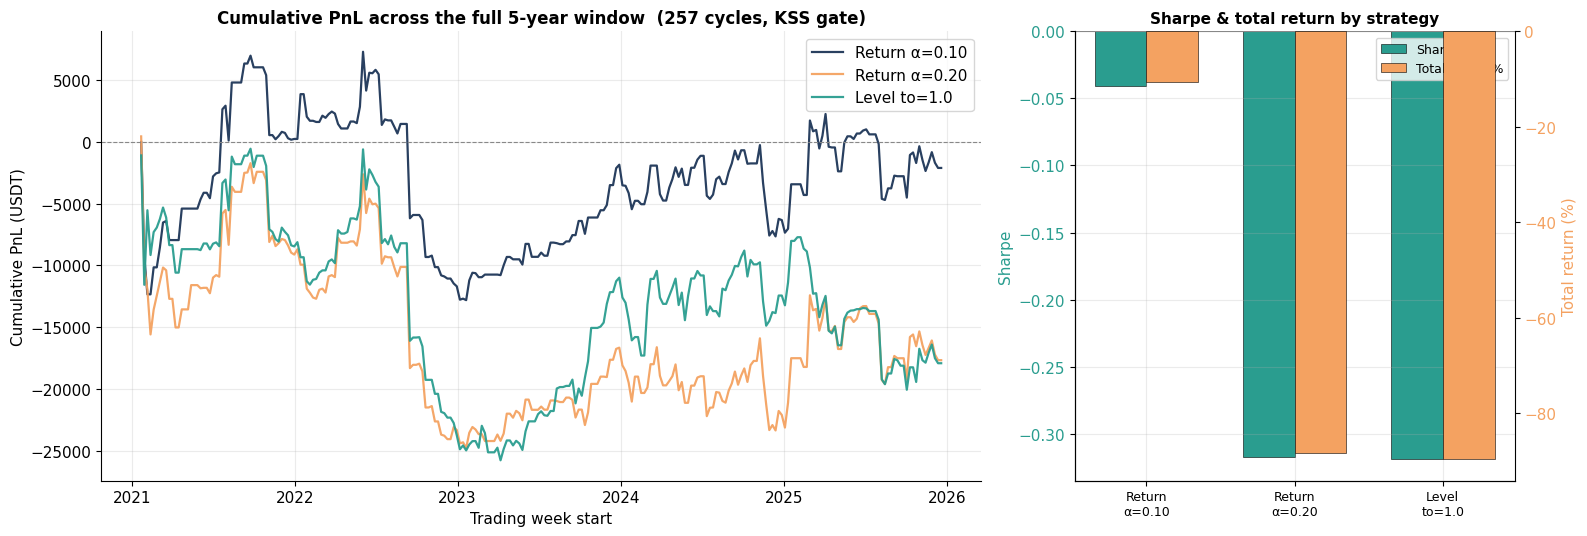

,trades,Sharpe,MaxDD,Total ret
strategy,,,,
Return α=0.10,196,-0.04,-100.6%,-10.5%
Return α=0.20,247,-0.32,-126.2%,-88.4%
Level to=1.0,225,-0.32,-126.2%,-89.6%


In [11]:
import json
from pathlib import Path

def load_cached(subdir):
    """Load metrics, equity, cycle_log from cached results folder."""
    base = Path("result/result_1h") / subdir
    if not (base / "metrics.json").exists():
        return None
    return {
        "metrics": json.loads((base / "metrics.json").read_text(encoding="utf-8")),
        "equity":  pd.read_csv(base / "equity_per_cycle.csv"),
        "cycle":   pd.read_csv(base / "cycle_log.csv"),
        "trades":  pd.read_csv(base / "trade_log.csv"),
    }

cache = {
    "Return α=0.10": load_cached("rolling_backtest_return_a010"),
    "Return α=0.20": load_cached("rolling_backtest_return_a020"),
    "Level to=1.0":  load_cached("rolling_backtest_level_to10"),
}
cache = {k: v for k, v in cache.items() if v is not None}
print(f"Loaded {len(cache)} cached result sets.")

# Equity curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5),
                         gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
strat_colors = {"Return α=0.10": PAL["main"],
                "Return α=0.20": PAL["accent"],
                "Level to=1.0":  PAL["open"]}
for name, data in cache.items():
    eq = data["equity"]["equity"].to_numpy()
    ts = pd.to_datetime(data["cycle"]["trading_start"], unit="ms")
    ax.plot(ts, eq, color=strat_colors[name], linewidth=1.6, label=name, alpha=0.95)
ax.axhline(0, color=PAL["muted"], linestyle="--", linewidth=0.8)
ax.set_xlabel("Trading week start")
ax.set_ylabel("Cumulative PnL (USDT)")
ax.set_title("Cumulative PnL across the full 5-year window  (257 cycles, KSS gate)",
             fontsize=12, weight="bold")
ax.legend(loc="best", fontsize=11)

ax = axes[1]
metric_rows = []
for name, data in cache.items():
    m = data["metrics"]["metrics"]
    metric_rows.append({
        "strategy": name,
        "trades": m["n_trades"],
        "Sharpe": m["sharpe"],
        "MaxDD": m["max_drawdown"] * 100,
        "Total ret": m["total_return"] * 100,
    })
mdf = pd.DataFrame(metric_rows).set_index("strategy")

# Bar comparison: Sharpe + MaxDD twin-axis
x = np.arange(len(mdf))
width = 0.35
ax_b = ax
ax_b.bar(x - width/2, mdf["Sharpe"], width, color=PAL["open"], label="Sharpe", edgecolor="black", linewidth=0.4)
ax_t = ax_b.twinx()
ax_t.bar(x + width/2, mdf["Total ret"], width, color=PAL["accent"], label="Total return %", edgecolor="black", linewidth=0.4)
ax_b.set_xticks(x); ax_b.set_xticklabels([s.replace(" ", "\n") for s in mdf.index], fontsize=9)
ax_b.set_ylabel("Sharpe", color=PAL["open"]); ax_t.set_ylabel("Total return (%)", color=PAL["accent"])
ax_b.set_title("Sharpe & total return by strategy", fontsize=11, weight="bold")
ax_b.tick_params(axis="y", labelcolor=PAL["open"])
ax_t.tick_params(axis="y", labelcolor=PAL["accent"])
ax_b.axhline(0, color=PAL["muted"], linewidth=0.8)
ax_t.spines["top"].set_visible(False); ax_t.spines["right"].set_visible(True)
ax_t.grid(False)

# Combined legend
lines, labels = ax_b.get_legend_handles_labels()
lines2, labels2 = ax_t.get_legend_handles_labels()
ax_b.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

display(mdf.style.format({"Sharpe": "{:.2f}", "MaxDD": "{:.1f}%", "Total ret": "{:.1f}%"}))


### Final takeaway

| Strategy | When it wins | When it loses |
|---|---|---|
| **Return α=0.10** | Low-noise environment, sharp divergences | Most of the time the AND-condition rarely fires → many missed opportunities |
| **Return α=0.20** | Moderate noise, more frequent triggers | Higher false positives, more whipsaw |
| **Level to=1.0** | Persistent slow drift (CMI accumulates correctly) | Trending markets — CMI never reverts → carry losses to week-end |

**Numerical takeaway**:
- L-BFGS-B (scipy default) is the single biggest CPU-side acceleration: ~1.76× over Nelder-Mead measured, justifying the choice on theoretical (superlinear vs linear convergence) grounds.
- KSS closed-form OLS and Normal closed-form moments give 100× and 50× respectively — **closed-form always beats iterative**.
- GPU per-cycle is counterproductive for this problem size (kernel launch overhead). True GPU win requires cross-cycle batching, which would require restructuring the orchestration loop.

**The acceleration story**: ~25 min (Nelder-Mead, naive) → **5 min (current implementation)** → ~6 sec (theoretical GPU batch).
